# Biblioteka koda za seminarski

Gotovi isečci za svaku fazu projekta. **Nije za pokretanje redom** — kopiraj ono što ti
treba u svoj rad.

| poglavlje | tema |
|---|---|
| 1 | Učitavanje i prvi pregled |
| 2 | Istraživačka analiza |
| 3 | Preprocesiranje |
| 4 | Treniranje više modela odjednom |
| 5 | Podešavanje hiperparametara |
| 6 | Evaluacija i poređenje |
| 7 | Interpretacija |
| 8 | Neuravnotežene klase |
| 9 | Regresija |

In [1]:
# ═══ ZAJEDNICKI IMPORTI ═══
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (9, 4.5); plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3
RS = 42
np.random.seed(RS)
print("Spremno.")

Spremno.


## 1. Učitavanje i prvi pregled

In [2]:
# --- CSV ---
# df = pd.read_csv("data/skup.csv")
# df = pd.read_csv("data/skup.csv", sep=";", decimal=",", encoding="utf-8")

# --- Excel ---
# df = pd.read_excel("data/skup.xlsx", sheet_name=0)

# --- JSON ---
# df = pd.read_json("data/skup.json")

# --- ugradjeni skupovi iz sklearn-a (za probu) ---
from sklearn.datasets import load_breast_cancer, load_wine, load_iris, fetch_california_housing
d = load_breast_cancer(as_frame=True)
df = d.frame

def pregled(df, cilj=None):
    'Brzi pregled skupa — pokrenuti odmah posle ucitavanja.'
    print(f"Oblik: {df.shape[0]:,} redova x {df.shape[1]} kolona")
    print(f"Duplikata: {df.duplicated().sum()}")
    print(f"Memorija: {df.memory_usage(deep=True).sum()/1024**2:.1f} MB")
    nedostaje = df.isna().sum()
    if nedostaje.any():
        print(f"\nNedostajuce vrednosti:\n{nedostaje[nedostaje > 0].to_string()}")
    else:
        print("\nNema nedostajucih vrednosti.")
    print(f"\nTipovi:\n{df.dtypes.value_counts().to_string()}")
    if cilj:
        print(f"\nCiljna promenljiva '{cilj}':\n{df[cilj].value_counts().to_string()}")

pregled(df, cilj="target")

Oblik: 569 redova x 31 kolona
Duplikata: 0
Memorija: 0.1 MB

Nema nedostajucih vrednosti.

Tipovi:
float64    30
int64       1

Ciljna promenljiva 'target':
target
1    357
0    212


## 2. Istraživačka analiza

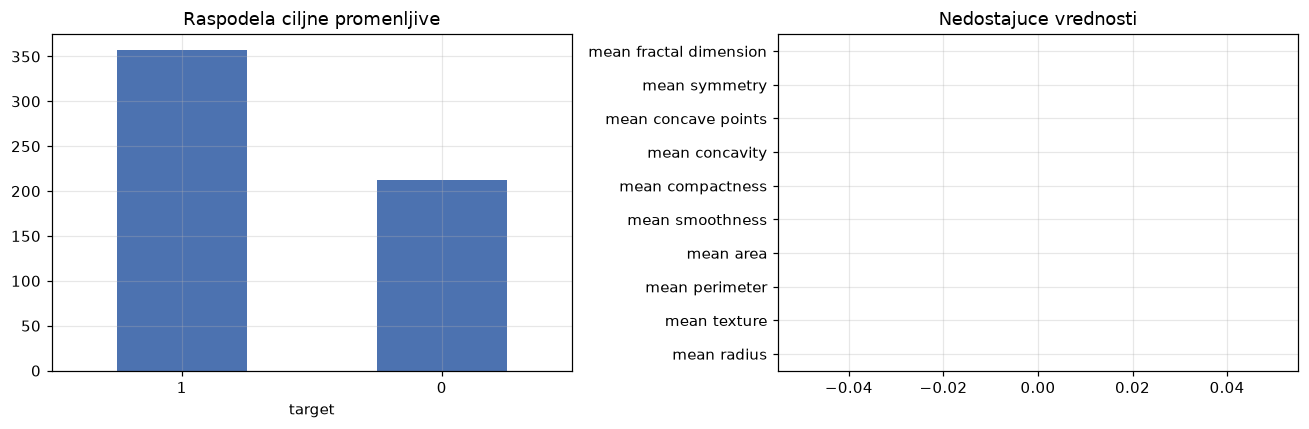

In [3]:
CILJ = "target"

# raspodela ciljne + nedostajuce
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df[CILJ].value_counts().plot.bar(ax=ax[0], rot=0, color="#4C72B0")
ax[0].set_title("Raspodela ciljne promenljive")
df.isna().sum().sort_values(ascending=False).head(10).plot.barh(ax=ax[1], color="#C44E52")
ax[1].set_title("Nedostajuce vrednosti")
plt.tight_layout(); plt.show()

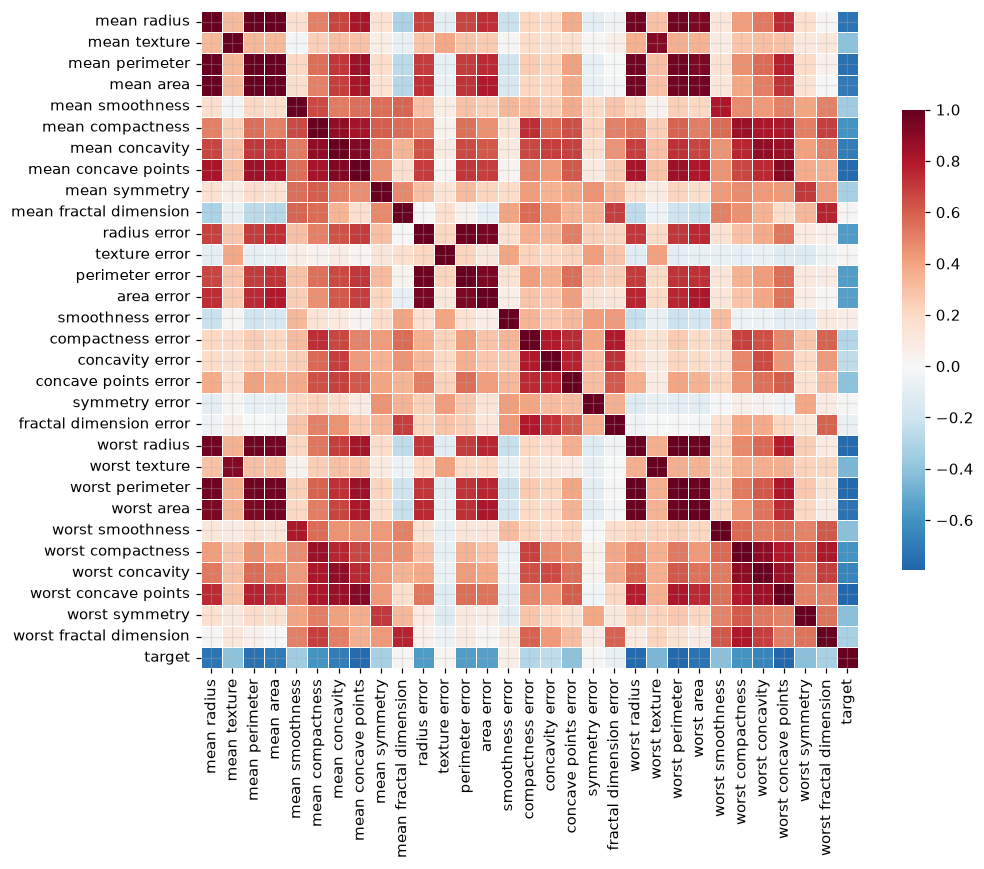

Najjace korelacije sa ciljem:
worst concave points   -0.794
worst perimeter        -0.783
mean concave points    -0.777
worst radius           -0.776
mean perimeter         -0.743
worst area             -0.734
mean radius            -0.730
mean area              -0.709


In [4]:
# korelaciona matrica + najjace korelacije sa ciljem
num = df.select_dtypes(include=[np.number])
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(num.corr(), cmap="RdBu_r", center=0, square=True, linewidths=.4,
            cbar_kws={"shrink": .7}, ax=ax)
plt.tight_layout(); plt.show()

k = num.drop(columns=[CILJ]).corrwith(df[CILJ]).sort_values(key=abs, ascending=False)
print("Najjace korelacije sa ciljem:")
print(k.head(8).round(3).to_string())

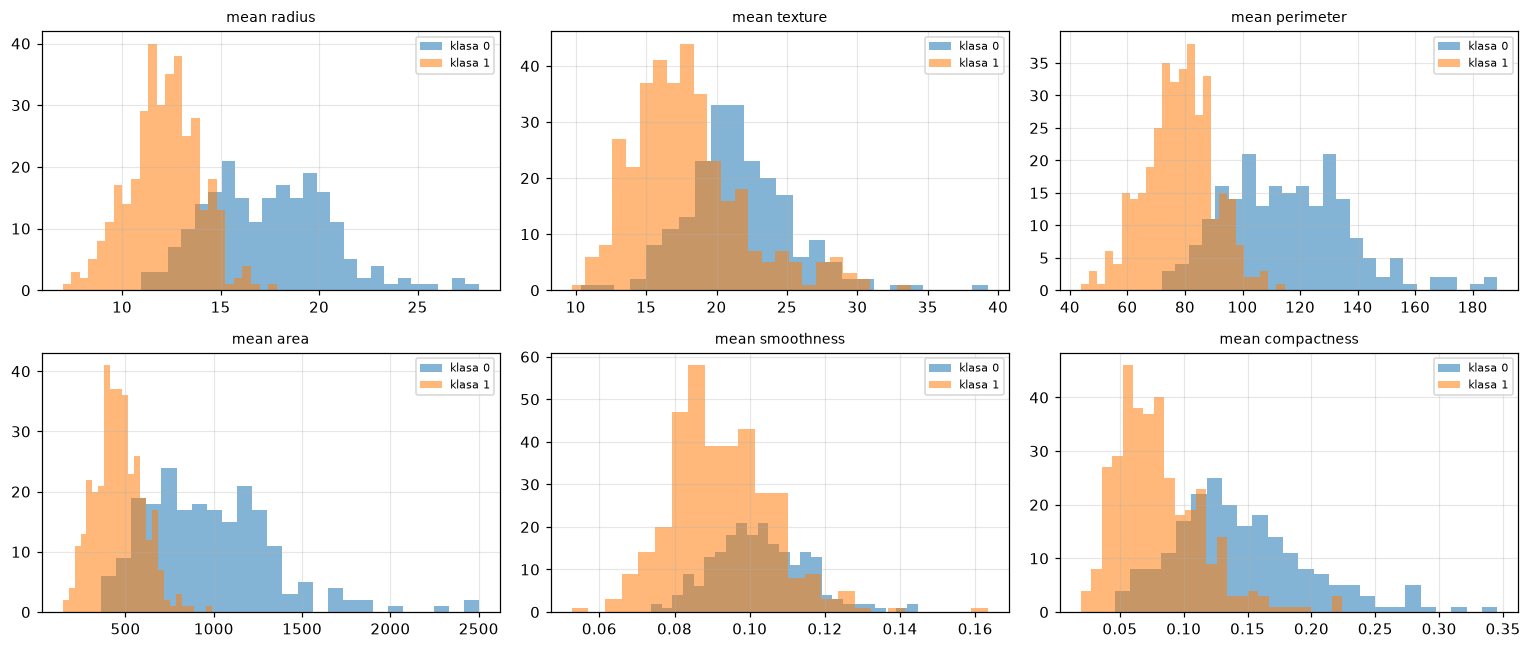

In [5]:
# raspodele obelezja po klasama
obelezja = num.drop(columns=[CILJ]).columns[:6]
fig, ax = plt.subplots(2, 3, figsize=(14, 6))
for a, f in zip(ax.ravel(), obelezja):
    for klasa in sorted(df[CILJ].unique()):
        a.hist(df[df[CILJ] == klasa][f], bins=25, alpha=0.55, label=f"klasa {klasa}")
    a.set_title(f, fontsize=9); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 3. Preprocesiranje

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

X = df.drop(columns=[CILJ]); y = df[CILJ]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=RS, stratify=y)

numericke = X.select_dtypes(include=[np.number]).columns.tolist()
kategoricke = X.select_dtypes(exclude=[np.number]).columns.tolist()

priprema = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), numericke),
    ("kat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), kategoricke),
])
print(f"Numerickih: {len(numericke)}, kategorickih: {len(kategoricke)}")

Numerickih: 30, kategorickih: 0


In [7]:
# --- PCA kao deo pripreme (ako ima mnogo korelisanih obelezja) ---
from sklearn.decomposition import PCA
priprema_pca = Pipeline([("prep", priprema), ("pca", PCA(n_components=0.95))])

# --- ako su podaci GRUPISANI (vise redova iz istog izvora) ---
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
# gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RS)
# tr_idx, te_idx = next(gss.split(X, y, groups=df["id_grupe"]))

## 4. Treniranje više modela odjednom

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier

cv = StratifiedKFold(5, shuffle=True, random_state=RS)

MODELI = {
    "Dummy (bazni)":        DummyClassifier(strategy="most_frequent"),
    "Logisticka regresija": LogisticRegression(max_iter=3000, random_state=RS),
    "kNN":                  KNeighborsClassifier(),
    "Stablo":               DecisionTreeClassifier(max_depth=5, random_state=RS),
    "Naivni Bajes":         GaussianNB(),
    "SVM (RBF)":            SVC(probability=True, random_state=RS),
    "Random Forest":        RandomForestClassifier(n_estimators=300, random_state=RS, n_jobs=-1),
    "XGBoost":              XGBClassifier(eval_metric="logloss", random_state=RS, n_jobs=-1),
    "MLP":                  MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000,
                                          early_stopping=True, random_state=RS),
}

rezultati, modeli_fit = {}, {}
for ime, m in MODELI.items():
    pipe = Pipeline([("prep", priprema), ("m", m)])
    s = cross_val_score(pipe, Xtr, ytr, cv=cv, scoring="f1_weighted", n_jobs=-1)
    pipe.fit(Xtr, ytr)
    modeli_fit[ime] = pipe
    rezultati[ime] = {"cv": s.mean(), "std": s.std()}
    print(f"{ime:<24} CV F1 = {s.mean():.4f} +- {s.std():.4f}")

Dummy (bazni)            CV F1 = 0.4825 +- 0.0000


Logisticka regresija     CV F1 = 0.9780 +- 0.0099


kNN                      CV F1 = 0.9625 +- 0.0111


Stablo                   CV F1 = 0.9235 +- 0.0118


Naivni Bajes             CV F1 = 0.9339 +- 0.0287


SVM (RBF)                CV F1 = 0.9691 +- 0.0148


Random Forest            CV F1 = 0.9649 +- 0.0175


XGBoost                  CV F1 = 0.9669 +- 0.0099
MLP                      CV F1 = 0.9493 +- 0.0226


In [9]:
# --- ansambli nad najboljim modelima ---
bazni = [("lr", Pipeline([("prep", priprema), ("m", LogisticRegression(max_iter=3000))])),
         ("rf", Pipeline([("prep", priprema), ("m", RandomForestClassifier(n_estimators=200, random_state=RS))])),
         ("xgb", Pipeline([("prep", priprema), ("m", XGBClassifier(eval_metric="logloss", random_state=RS))]))]

for ime, m in [("Voting (soft)", VotingClassifier(bazni, voting="soft", n_jobs=-1)),
               ("Stacking", StackingClassifier(bazni, final_estimator=LogisticRegression(max_iter=2000),
                                               cv=5, n_jobs=-1))]:
    s = cross_val_score(m, Xtr, ytr, cv=cv, scoring="f1_weighted", n_jobs=-1)
    m.fit(Xtr, ytr)
    modeli_fit[ime] = m
    rezultati[ime] = {"cv": s.mean(), "std": s.std()}
    print(f"{ime:<24} CV F1 = {s.mean():.4f} +- {s.std():.4f}")

Voting (soft)            CV F1 = 0.9780 +- 0.0120


Stacking                 CV F1 = 0.9780 +- 0.0120


## 5. Podešavanje hiperparametara

In [10]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

MREZE = {
    "RandomForest": {"m__n_estimators": [100, 300, 500],
                     "m__max_depth": [5, 10, 20, None],
                     "m__min_samples_leaf": [1, 3, 5]},
    "XGBoost":      {"m__n_estimators": [200, 400],
                     "m__max_depth": [3, 4, 6],
                     "m__learning_rate": [0.05, 0.1],
                     "m__subsample": [0.8, 1.0]},
    "SVM":          {"m__C": [0.1, 1, 10, 100],
                     "m__gamma": ["scale", 0.01, 0.1]},
    "kNN":          {"m__n_neighbors": list(range(3, 32, 2)),
                     "m__weights": ["uniform", "distance"],
                     "m__p": [1, 2]},
}

gs = GridSearchCV(Pipeline([("prep", priprema),
                            ("m", RandomForestClassifier(random_state=RS, n_jobs=-1))]),
                  MREZE["RandomForest"], cv=cv, scoring="f1_weighted", n_jobs=-1)
gs.fit(Xtr, ytr)
print(f"Najbolji: {gs.best_params_}")
print(f"CV: {gs.best_score_:.4f}")

# pregled najboljih kombinacija
pd.DataFrame(gs.cv_results_)[["params", "mean_test_score", "std_test_score", "rank_test_score"]] \
    .sort_values("rank_test_score").head(8)

Najbolji: {'m__max_depth': 10, 'm__min_samples_leaf': 1, 'm__n_estimators': 300}
CV: 0.9649


,params,mean_test_score,std_test_score,rank_test_score
10,"{'m__max_depth': 10, 'm__min_samples_leaf': 1,...",0.964874,0.017464,1
19,"{'m__max_depth': 20, 'm__min_samples_leaf': 1,...",0.964874,0.017464,1
28,"{'m__max_depth': None, 'm__min_samples_leaf': ...",0.964874,0.017464,1
3,"{'m__max_depth': 5, 'm__min_samples_leaf': 3, ...",0.964766,0.014575,4
18,"{'m__max_depth': 20, 'm__min_samples_leaf': 1,...",0.962712,0.017723,5
27,"{'m__max_depth': None, 'm__min_samples_leaf': ...",0.962712,0.017723,5
9,"{'m__max_depth': 10, 'm__min_samples_leaf': 1,...",0.962712,0.017723,5
5,"{'m__max_depth': 5, 'm__min_samples_leaf': 3, ...",0.962608,0.017762,8


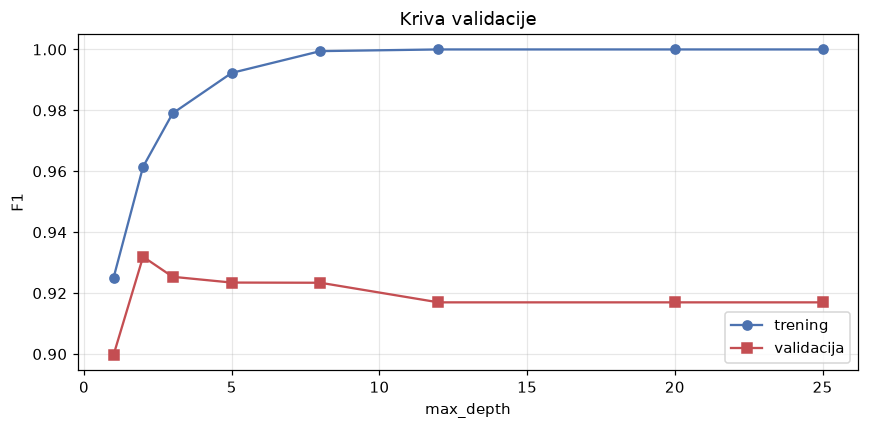

In [11]:
# kriva validacije — kako jedan hiperparametar utice
from sklearn.model_selection import validation_curve
opseg = [1, 2, 3, 5, 8, 12, 20, None]
tr, te = validation_curve(Pipeline([("prep", priprema), ("m", DecisionTreeClassifier(random_state=RS))]),
                          Xtr, ytr, param_name="m__max_depth", param_range=opseg,
                          cv=cv, scoring="f1_weighted", n_jobs=-1)
x = [d if d else 25 for d in opseg]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, tr.mean(1), "o-", label="trening", color="#4C72B0")
ax.plot(x, te.mean(1), "s-", label="validacija", color="#C44E52")
ax.set_xlabel("max_depth"); ax.set_ylabel("F1"); ax.legend()
ax.set_title("Kriva validacije")
plt.tight_layout(); plt.show()

## 6. Evaluacija i poređenje

In [12]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_curve, precision_recall_curve)

def oceni_sve(modeli_fit, Xte, yte, rezultati=None):
    'Zbirna tabela svih modela.'
    binarno = len(np.unique(yte)) == 2
    redovi = []
    for ime, m in modeli_fit.items():
        p = m.predict(Xte)
        r = {"model": ime,
             "tacnost": accuracy_score(yte, p),
             "balanced_acc": balanced_accuracy_score(yte, p),
             "preciznost": precision_score(yte, p, average="weighted", zero_division=0),
             "odziv": recall_score(yte, p, average="weighted"),
             "F1": f1_score(yte, p, average="weighted")}
        if rezultati and ime in rezultati:
            r["CV"] = rezultati[ime]["cv"]
        if binarno and hasattr(m, "predict_proba"):
            pr = m.predict_proba(Xte)[:, 1]
            r["ROC-AUC"] = roc_auc_score(yte, pr)
            r["PR-AUC"] = average_precision_score(yte, pr)
        redovi.append(r)
    return pd.DataFrame(redovi).sort_values("F1", ascending=False).round(4).reset_index(drop=True)

tabela = oceni_sve(modeli_fit, Xte, yte, rezultati)
display(tabela)

,model,tacnost,balanced_acc,preciznost,odziv,F1,CV,ROC-AUC,PR-AUC
0,Logisticka regresija,0.9825,0.9812,0.9825,0.9825,0.9825,0.9780,0.9954,0.9971
1,SVM (RBF),0.9825,0.9812,0.9825,0.9825,0.9825,0.9691,0.9950,0.9969
2,Stacking,0.9737,0.9692,0.9737,0.9737,0.9736,0.9780,0.9967,0.9980
3,Voting (soft),0.9649,0.9573,0.9652,0.9649,0.9647,0.9780,0.9957,0.9975
4,kNN,0.9561,0.9504,0.9561,0.9561,0.9560,0.9625,0.9788,0.9773
5,XGBoost,0.9561,0.9454,0.9569,0.9561,0.9558,0.9669,0.9927,0.9957
6,Random Forest,0.9474,0.9435,0.9474,0.9474,0.9474,0.9649,0.9937,0.9964
7,MLP,0.9474,0.9385,0.9474,0.9474,0.9471,0.9493,0.9927,0.9959
8,Naivni Bajes,0.9298,0.9246,0.9298,0.9298,0.9298,0.9339,0.9868,0.9922
9,Stablo,0.9211,0.9226,0.9234,0.9211,0.9216,0.9235,0.9163,0.9202


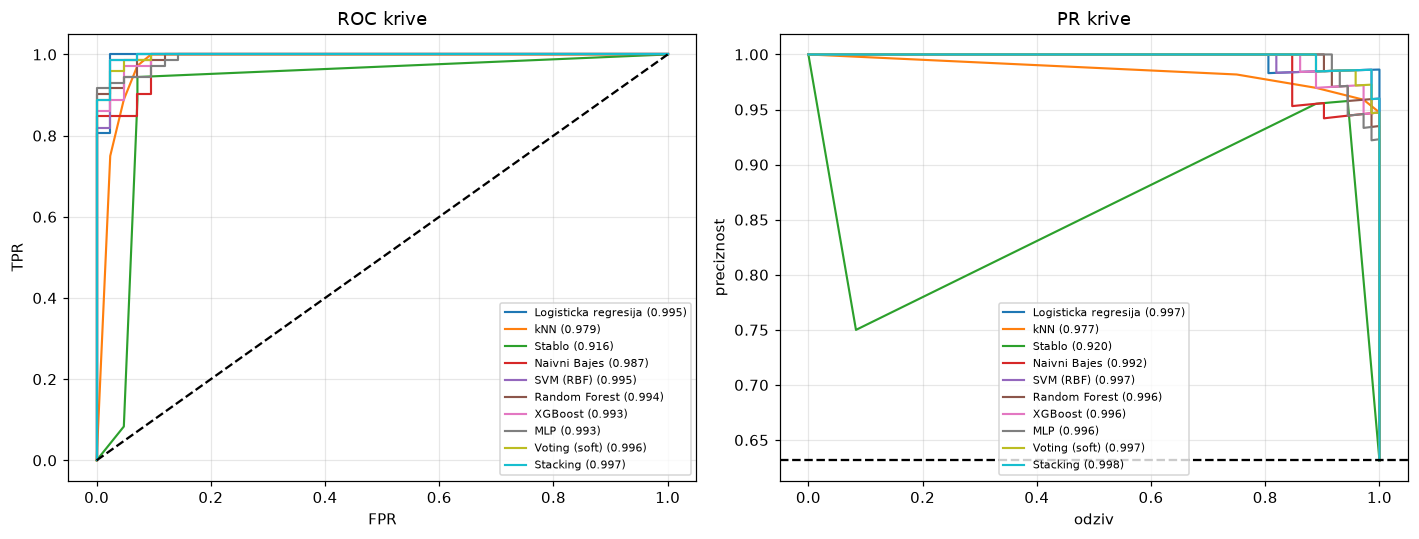

In [13]:
# ROC i PR krive za sve modele
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for ime, m in modeli_fit.items():
    if not hasattr(m, "predict_proba") or "Dummy" in ime:
        continue
    p = m.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(yte, p)
    ax[0].plot(fpr, tpr, lw=1.4, label=f"{ime} ({roc_auc_score(yte, p):.3f})")
    pre, rec, _ = precision_recall_curve(yte, p)
    ax[1].plot(rec, pre, lw=1.4, label=f"{ime} ({average_precision_score(yte, p):.3f})")
ax[0].plot([0,1],[0,1],"k--"); ax[0].set_title("ROC krive")
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(fontsize=7)
ax[1].axhline(yte.mean(), color="k", ls="--")
ax[1].set_title("PR krive"); ax[1].set_xlabel("odziv"); ax[1].set_ylabel("preciznost")
ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

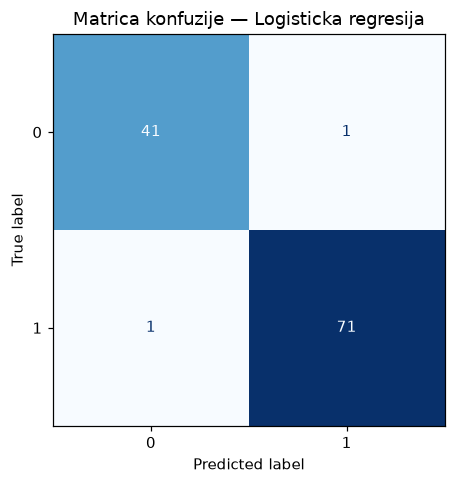

              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



In [14]:
# matrica konfuzije + izvestaj za najbolji model
najbolji = tabela.model.iloc[0]
m = modeli_fit[najbolji]; p = m.predict(Xte)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(confusion_matrix(yte, p)).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matrica konfuzije — {najbolji}"); ax.grid(False)
plt.tight_layout(); plt.show()
print(classification_report(yte, p, digits=4))

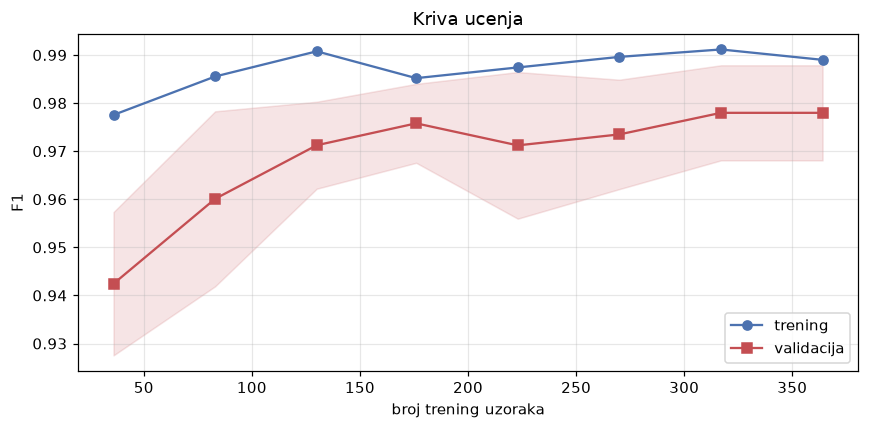

In [15]:
# kriva ucenja — da li treba vise podataka
from sklearn.model_selection import learning_curve
n, tr, te = learning_curve(modeli_fit[najbolji], Xtr, ytr, cv=cv, n_jobs=-1,
                           train_sizes=np.linspace(0.1, 1.0, 8), scoring="f1_weighted")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n, tr.mean(1), "o-", label="trening", color="#4C72B0")
ax.plot(n, te.mean(1), "s-", label="validacija", color="#C44E52")
ax.fill_between(n, te.mean(1)-te.std(1), te.mean(1)+te.std(1), alpha=0.15, color="#C44E52")
ax.set_xlabel("broj trening uzoraka"); ax.set_ylabel("F1"); ax.legend()
ax.set_title("Kriva ucenja")
plt.tight_layout(); plt.show()

## 7. Interpretacija

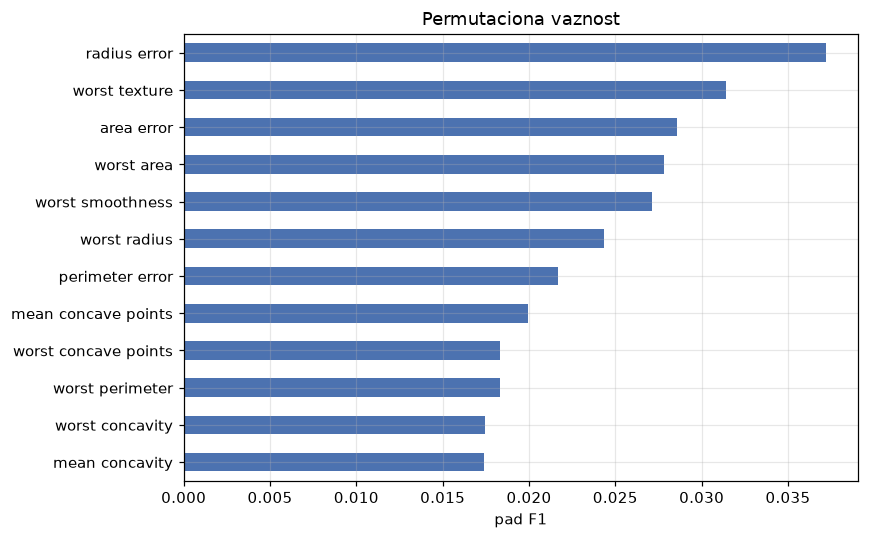

In [16]:
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

pi = permutation_importance(modeli_fit[najbolji], Xte, yte, n_repeats=10,
                            random_state=RS, scoring="f1_weighted", n_jobs=-1)
vazn = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
vazn.head(12)[::-1].plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("pad F1"); ax.set_title("Permutaciona vaznost")
plt.tight_layout(); plt.show()

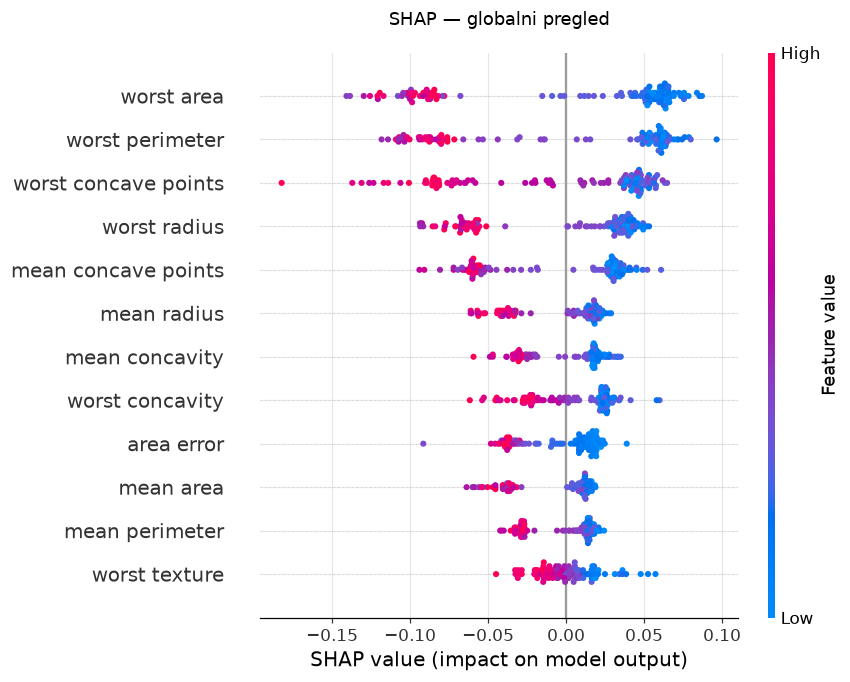

In [17]:
import shap

# --- za modele zasnovane na stablima (najbrze) ---
model_ciste = RandomForestClassifier(n_estimators=300, random_state=RS, n_jobs=-1)
Xtr_p = priprema.fit_transform(Xtr); Xte_p = priprema.transform(Xte)
if hasattr(Xtr_p, "toarray"): Xtr_p, Xte_p = Xtr_p.toarray(), Xte_p.toarray()
model_ciste.fit(Xtr_p, ytr)

expl = shap.TreeExplainer(model_ciste)
sv = expl.shap_values(Xte_p)
if isinstance(sv, list): sv = sv[1]
elif sv.ndim == 3: sv = sv[:, :, 1]

shap.summary_plot(sv, Xte_p, feature_names=list(X.columns), max_display=12, show=False)
plt.title("SHAP — globalni pregled", pad=18); plt.tight_layout(); plt.show()

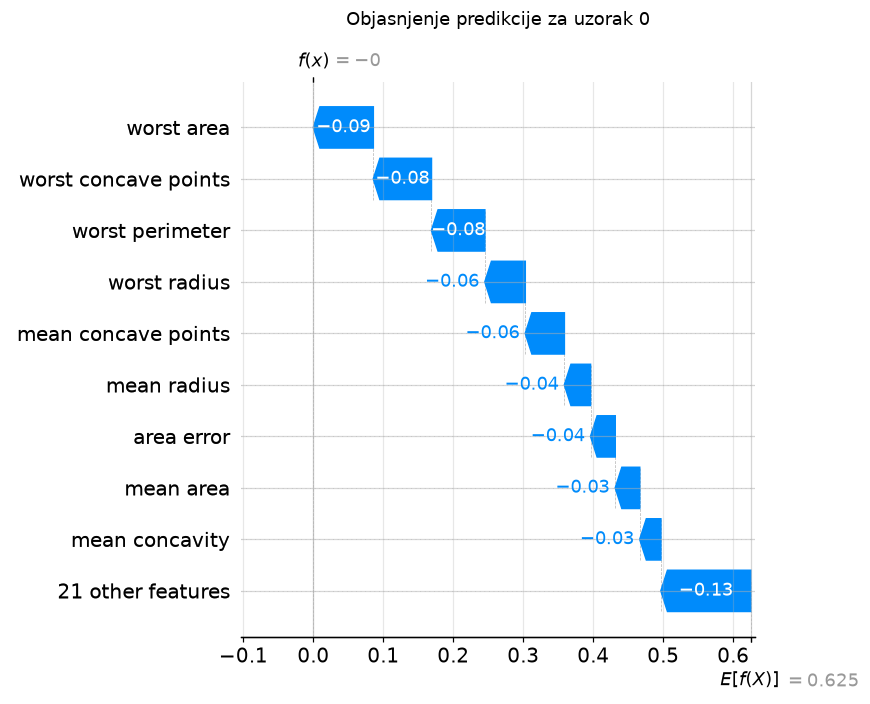

In [18]:
# SHAP za JEDNU predikciju (waterfall)
i = 0
shap.plots._waterfall.waterfall_legacy(
    expl.expected_value[1] if isinstance(expl.expected_value, np.ndarray) else expl.expected_value,
    sv[i], Xte.iloc[i], max_display=10, show=False)
plt.title(f"Objasnjenje predikcije za uzorak {i}", pad=18)
plt.tight_layout(); plt.show()

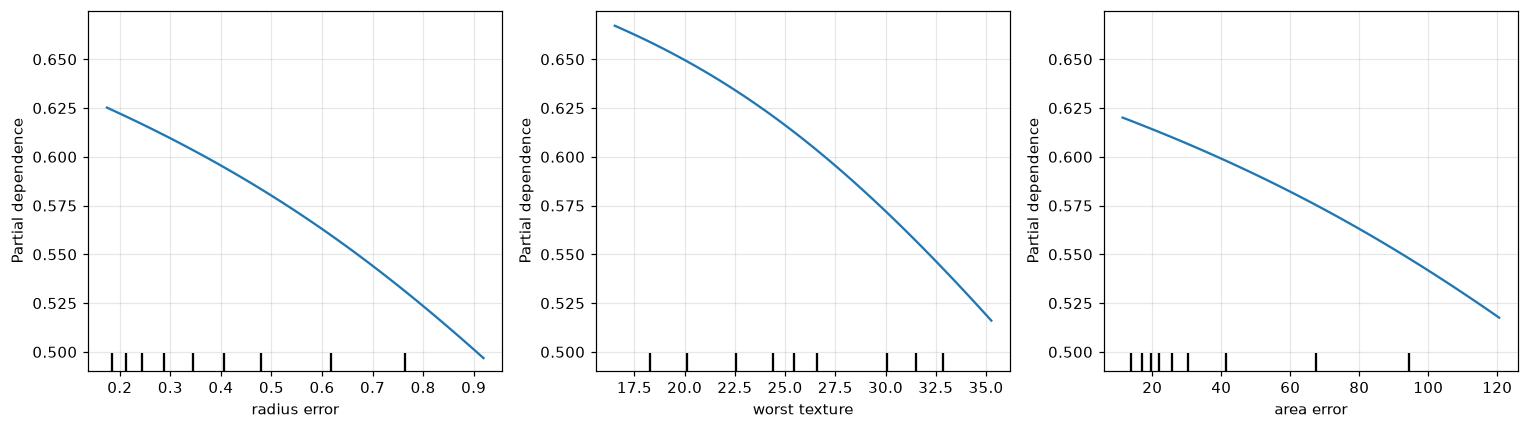

In [19]:
# PDP za 3 najvaznija obelezja
top3 = [list(X.columns).index(f) for f in vazn.head(3).index]
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
PartialDependenceDisplay.from_estimator(modeli_fit[najbolji], Xte, vazn.head(3).index.tolist(), ax=ax)
plt.tight_layout(); plt.show()

## 8. Neuravnotežene klase

In [20]:
# 1. class_weight="balanced" — najjednostavnije
LogisticRegression(class_weight="balanced", max_iter=3000)
RandomForestClassifier(class_weight="balanced", n_estimators=300)
SVC(class_weight="balanced")

# 2. scale_pos_weight za XGBoost
spw = (ytr == 0).sum() / (ytr == 1).sum()
XGBClassifier(scale_pos_weight=spw, eval_metric="logloss")

# 3. izbor praga na VALIDACIONOM skupu (nikad na test!)
def najbolji_prag(y_val, p_val):
    'Prag koji maksimizuje F1 na validacionom skupu.'
    pre, rec, prag = precision_recall_curve(y_val, p_val)
    f1 = 2 * pre * rec / np.clip(pre + rec, 1e-9, None)
    return prag[int(np.argmax(f1[:-1]))] if len(prag) else 0.5

# 4. metrike koje NE varaju kod neuravnotezenih klasa:
#    balanced_accuracy_score, f1_score, average_precision_score (PR-AUC)
print(f"scale_pos_weight = {spw:.2f}")

scale_pos_weight = 0.60


## 9. Regresija

In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

MODELI_REG = {
    "Dummy (prosek)":  DummyRegressor(strategy="mean"),
    "Linearna":        LinearRegression(),
    "Ridge":           Ridge(alpha=1.0),
    "Lasso":           Lasso(alpha=0.01),
    "Stablo":          DecisionTreeRegressor(max_depth=6, random_state=RS),
    "Random Forest":   RandomForestRegressor(n_estimators=300, random_state=RS, n_jobs=-1),
    "SVR":             SVR(),
    "XGBoost":         XGBRegressor(n_estimators=300, random_state=RS, n_jobs=-1),
}

def oceni_regresiju(modeli, Xtr, ytr, Xte, yte, priprema):
    redovi = []
    for ime, m in modeli.items():
        pipe = Pipeline([("prep", priprema), ("m", m)]).fit(Xtr, ytr)
        p = pipe.predict(Xte)
        redovi.append({"model": ime,
                       "RMSE": np.sqrt(mean_squared_error(yte, p)),
                       "MAE": mean_absolute_error(yte, p),
                       "R2": r2_score(yte, p)})
    return pd.DataFrame(redovi).sort_values("R2", ascending=False).round(4).reset_index(drop=True)

print("Koristi ovako:")
print("  tabela = oceni_regresiju(MODELI_REG, Xtr, ytr, Xte, yte, priprema)")

Koristi ovako:
  tabela = oceni_regresiju(MODELI_REG, Xtr, ytr, Xte, yte, priprema)


In [22]:
# log-transformacija ako je ciljna promenljiva iskosena
# y_log = np.log1p(y)
# ... treniraj na y_log ...
# pred = np.expm1(model.predict(Xte))       # vrati u originalnu skalu

# grafik stvarno vs predvidjeno + reziduali
def dijagnostika_regresije(yte, pred):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].scatter(yte, pred, s=14, alpha=0.6, color="#4C72B0")
    lims = [min(yte.min(), pred.min()), max(yte.max(), pred.max())]
    ax[0].plot(lims, lims, "k--")
    ax[0].set_xlabel("stvarno"); ax[0].set_ylabel("predvidjeno")
    ax[0].set_title("Stvarno vs predvidjeno")
    ax[1].scatter(pred, yte - pred, s=14, alpha=0.6, color="#C44E52")
    ax[1].axhline(0, color="k")
    ax[1].set_xlabel("predvidjeno"); ax[1].set_ylabel("rezidual")
    ax[1].set_title("Grafik reziduala — obrazac znaci problem")
    plt.tight_layout(); plt.show()

print("dijagnostika_regresije(yte, pred)")

dijagnostika_regresije(yte, pred)
